# Graph Attention Networks, from scratch (single head)

This is the companion to `gcn-from-scratch.ipynb`. Same task (semi-supervised
node classification), same graphs (Zachary's Karate Club, then Cora), same
plain-PyTorch-only rule (`networkx` for I/O only) — the **one** thing we
change is the aggregation step inside the layer.

Recall the GCN layer: `H_out = A_hat @ (H @ W)`, where `A_hat` is a *fixed*
matrix computed once from node degrees, before training ever starts. Every
neighbor of node *i* gets a weight that depends only on how many neighbors
*i* and that neighbor have — never on what either node's features actually
say.

A Graph Attention layer (Veličković et al., 2018, *"Graph Attention
Networks"*) replaces that fixed weight with a **learned, feature-dependent**
one: `H_out = alpha @ (H @ W)`, where `alpha` is recomputed from the current
features on every forward pass via an attention mechanism, and trained end
to end with everything else.

**Plan**, mirroring the GCN notebook section for section so results are
directly comparable:
1. Reload Karate Club exactly as before, but keep the *raw* adjacency (no
   degree normalization needed this time — attention will learn its own
   weighting).
2. Derive the attention score and implement a single GAT layer from scratch.
3. Stack two layers into a full model.
4. Reuse the *exact same* semi-supervised split and training hyperparameters
   as the GCN notebook, changing nothing but the layer, so any accuracy
   difference is attributable to attention vs. fixed normalization — not to
   incidental tuning.
5. Compare final accuracy directly against the GCN run: **96.88%** held-out
   on Karate Club, **81.80%** test accuracy on Cora.
6. Visualize the learned attention weights themselves — something a GCN has
   no analogue of, since its weights are fixed before training starts.
7. (Stretch) Scale to Cora, again reusing the GCN notebook's exact data
   pipeline and hyperparameters.


In [1]:
import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

print("torch:", torch.__version__)
print("networkx:", nx.__version__)


torch: 2.14.0+cu130
networkx: 3.6.1


## 1. Load the graph — same data, but we stop at the *raw* adjacency

Everything here is identical to the GCN notebook's section 1: same graph,
same node ordering, same integer labels. The only difference is we do **not**
build `A_hat = D^{-1/2}(A+I)D^{-1/2}` this time. Attention doesn't need a
precomputed weighting — it computes its own. All we need from the graph
structure now is a *yes/no* mask: "is `j` allowed to influence `i`?" That
mask is `(A + I) > 0` — the `+ I` adds self-loops, exactly as in the GCN
notebook, so every node also attends to itself.


In [2]:
# --- Load the graph structure (identical to the GCN notebook) ---
G = nx.karate_club_graph()
N = G.number_of_nodes()
print(f"nodes: {N}, edges: {G.number_of_edges()}")

club_to_label = {"Mr. Hi": 0, "Officer": 1}
labels = torch.tensor(
    [club_to_label[G.nodes[i]["club"]] for i in range(N)], dtype=torch.long
)
print("label counts:", torch.bincount(labels).tolist())

# --- Raw adjacency, built by hand exactly as before ---
A = torch.zeros((N, N), dtype=torch.float32)
for u, v in G.edges():
    A[u, v] = 1.0
    A[v, u] = 1.0

# --- The only piece of graph structure a GAT layer consumes: a boolean mask
# of "who is allowed to attend to whom", including self-loops. Note this is
# NOT a weighted matrix like A_hat -- it carries no numbers of its own, only
# permission. All the numbers come from attention, computed below.
adj_mask = (A + torch.eye(N)) > 0
print("adj_mask shape:", adj_mask.shape, " dtype:", adj_mask.dtype)
print("average neighbors per node (incl. self):", adj_mask.sum(dim=1).float().mean().item())


nodes: 34, edges: 78
label counts: [17, 17]
adj_mask shape: torch.Size([34, 34])  dtype: torch.bool
average neighbors per node (incl. self): 5.588235378265381


## 2. Deriving the attention score

For an edge (or potential edge) from node *i* to node *j*, GAT computes a raw
attention score

$$e_{ij} = \text{LeakyReLU}\big(a^T [W h_i \,\Vert\, W h_j]\big)$$

where `W` is a shared linear transform (same role as GCN's `W`), `[· || ·]`
is concatenation, and `a` is a learned attention vector of length `2*F_out`.
Naively, computing this for every pair means building an `(N, N, 2*F_out)`
tensor of concatenated features — wasteful.

Notice `a` splits cleanly into two halves, `a = [a_src ; a_dst]`, each of
length `F_out`, so the dot product distributes over the concatenation:

$$a^T [Wh_i \Vert Wh_j] = a_{src}^T (Wh_i) + a_{dst}^T (Wh_j)$$

That means we can precompute a single scalar "source score" per node
(`a_src . Wh_i`) and a single scalar "destination score" per node
(`a_dst . Wh_j`), and get every pairwise `e_ij` at once as an **outer sum**:
`e = src_scores[:, None] + dst_scores[None, :]`, an `(N, F_out) -> (N,)`
reduction instead of an `(N, N, 2*F_out)` tensor. Same score, far cheaper.

Once we have `e`, we mask out every non-neighbor pair to `-inf` (so it gets
exactly zero weight after softmax — this is the paper's *masked attention*:
node *i* only ever competes its neighbors against each other, never against
the whole graph), then softmax each row so *i*'s incoming weights sum to 1,
exactly like a probability distribution over "which neighbor to listen to".


In [3]:
class GATLayer(nn.Module):
    """One graph-attention layer: H_out = alpha @ (H @ W), where `alpha`
    (unlike GCN's `A_hat`) is learned and recomputed every forward pass.

    Compare directly to GCNLayer: same `H @ W` linear transform, same
    aggregation *shape* (a matrix multiplied against the transformed
    features) -- the only change is where that aggregation matrix comes
    from.
    """

    def __init__(self, in_features: int, out_features: int, leaky_relu_slope: float = 0.2):
        super().__init__()
        self.W = nn.Parameter(torch.empty(in_features, out_features))
        nn.init.xavier_uniform_(self.W)

        # a_src, a_dst together are the paper's single attention vector `a`,
        # split into the half that multiplies node i's features and the half
        # that multiplies node j's -- see the derivation above.
        self.a_src = nn.Parameter(torch.empty(out_features))
        self.a_dst = nn.Parameter(torch.empty(out_features))
        nn.init.xavier_uniform_(self.a_src.view(1, -1))
        nn.init.xavier_uniform_(self.a_dst.view(1, -1))

        self.leaky_relu_slope = leaky_relu_slope

    def forward(self, H: torch.Tensor, adj_mask: torch.Tensor):
        Wh = H @ self.W  # (N, F_in) @ (F_in, F_out) -> (N, F_out), same as GCN's `support`

        # Per-node scalar scores, one dot product each -- the decomposition
        # from the derivation above.
        src_scores = Wh @ self.a_src  # (N,)  = a_src . Wh_i, for every i
        dst_scores = Wh @ self.a_dst  # (N,)  = a_dst . Wh_j, for every j

        # Outer sum reconstructs every pairwise e_ij = a_src.Wh_i + a_dst.Wh_j
        # without ever materializing a concatenated (N, N, 2*F_out) tensor.
        e = src_scores.unsqueeze(1) + dst_scores.unsqueeze(0)  # (N, N), e[i, j]
        e = F.leaky_relu(e, negative_slope=self.leaky_relu_slope)

        # Masked attention: forbid non-neighbors from receiving any weight at
        # all by sending their score to -inf before the softmax.
        e = e.masked_fill(~adj_mask, float("-inf"))

        # Softmax over j (dim=1): row i becomes a probability distribution
        # over i's actual neighbors (self included, via the self-loop in adj_mask).
        alpha = F.softmax(e, dim=1)  # (N, N)

        out = alpha @ Wh  # (N, N) @ (N, F_out) -> (N, F_out), same shape as GCN's `A_hat @ support`
        return out, alpha


# --- Smoke-test the layer in isolation, exactly like the GCN notebook did ---
X = torch.eye(N)  # same featureless (one-hot identity) setup as the GCN notebook

layer = GATLayer(in_features=N, out_features=4)
H1, alpha1 = layer(X, adj_mask)
print("input X shape:", X.shape)
print("output H1 shape:", H1.shape)
print("alpha shape (attention weights):", alpha1.shape)
print("each row of alpha sums to 1:", torch.allclose(alpha1.sum(dim=1), torch.ones(N)))
print("alpha is zero wherever adj_mask is False:", torch.allclose(alpha1[~adj_mask], torch.zeros_like(alpha1[~adj_mask])))

# --- Permutation-equivariance check, same logic as the GCN notebook: permute
# node order and confirm the layer's output permutes identically, using
# generic (non-identity) per-node features so row- vs column-permutation
# aren't accidentally conflated (same subtlety flagged in the GCN notebook).
X_generic = torch.randn(N, 6)
layer6 = GATLayer(in_features=6, out_features=4)

perm = torch.randperm(N)
X_perm = X_generic[perm]
adj_mask_perm = adj_mask[perm][:, perm]

H_out, _ = layer6(X_generic, adj_mask)
H_out_perm, _ = layer6(X_perm, adj_mask_perm)
print(
    "permuting nodes then running the layer == running the layer then permuting:",
    torch.allclose(H_out_perm, H_out[perm], atol=1e-6),
)


input X shape: torch.Size([34, 34])
output H1 shape: torch.Size([34, 4])
alpha shape (attention weights): torch.Size([34, 34])
each row of alpha sums to 1: True
alpha is zero wherever adj_mask is False: True
permuting nodes then running the layer == running the layer then permuting: True


## 3. Stacking two layers

The receptive-field argument from the GCN notebook carries over unchanged:
depth still equals hop-count, because `adj_mask` still only permits nonzero
weight between actual neighbors — a node at distance 2 still can't reach
layer 1's output directly, no matter how attention reweights the neighbors
that *are* allowed. Attention changes *how much* each neighbor counts, never
*which* nodes count. So we won't re-run the autograd receptive-field probe
here; it would show identical structural results to the GCN notebook's — the
only thing changing between the two models is the *numbers* inside that
fixed 1-hop / 2-hop footprint.

Same dropout scaffolding as the GCN model, for the same reason (Cora's much
worse label-to-parameter ratio later needs it; Karate Club runs it at 0.0,
a no-op).


In [4]:
class GAT(nn.Module):
    """Full 2-layer model: Layer 1 -> ReLU -> Layer 2 -> class logits.

    Structurally identical to the GCN class -- same two-layer shape, same
    ReLU (not the paper's ELU: we keep it as ReLU deliberately, so the
    nonlinearity matches the GCN notebook and attention-vs-fixed-aggregation
    is the only variable that changed). We also return both layers' attention
    matrices, for the visualization later.
    """

    def __init__(self, in_features: int, hidden_features: int, num_classes: int, dropout: float = 0.0):
        super().__init__()
        self.gat1 = GATLayer(in_features, hidden_features)
        self.gat2 = GATLayer(hidden_features, num_classes)
        self.dropout = dropout

    def forward(self, X: torch.Tensor, adj_mask: torch.Tensor):
        X = F.dropout(X, p=self.dropout, training=self.training)

        H1_raw, alpha1 = self.gat1(X, adj_mask)
        H1 = F.relu(H1_raw)

        H1_for_gat2 = F.dropout(H1, p=self.dropout, training=self.training)
        H2, alpha2 = self.gat2(H1_for_gat2, adj_mask)

        return H1, H2, alpha1, alpha2


model = GAT(in_features=N, hidden_features=4, num_classes=2)
H1, H2, alpha1, alpha2 = model(X, adj_mask)
print("H1 (after layer 1) shape:", H1.shape)
print("H2 (after layer 2, logits) shape:", H2.shape)
print("alpha1 shape:", alpha1.shape, " alpha2 shape:", alpha2.shape)


H1 (after layer 1) shape: torch.Size([34, 4])
H2 (after layer 2, logits) shape: torch.Size([34, 2])
alpha1 shape: torch.Size([34, 34])  alpha2 shape: torch.Size([34, 34])


## 4. The same semi-supervised split

Identical to the GCN notebook: nodes 0 ("Mr. Hi") and 33 ("Officer") are the
only labeled nodes; the model must infer the other 32 from structure plus
those 2 labels. Reusing the *exact same* two nodes keeps the comparison
apples-to-apples.


In [5]:
assert G.nodes[0]["club"] == "Mr. Hi"
assert G.nodes[33]["club"] == "Officer"

train_nodes = [0, 33]

train_mask = torch.zeros(N, dtype=torch.bool)
train_mask[train_nodes] = True
test_mask = ~train_mask

print("labeled (train) nodes:", train_nodes, "->", labels[train_mask].tolist())
print(f"train nodes: {train_mask.sum().item()} / {N}   test (held-out) nodes: {test_mask.sum().item()} / {N}")
print("classes present in train set:", torch.unique(labels[train_mask]).tolist())


labeled (train) nodes: [0, 33] -> [0, 1]
train nodes: 2 / 34   test (held-out) nodes: 32 / 34
classes present in train set: [0, 1]


## 5. Training

Every hyperparameter here is copied unchanged from the GCN notebook's
Karate Club run: `hidden_features=16`, Adam with `lr=0.01` and
`weight_decay=5e-4`, 200 epochs, `torch.manual_seed(42)` right before
building the model. The only thing that's different is the model class
itself (`GAT` instead of `GCN`). That makes the final accuracy comparison a
controlled experiment on the aggregation mechanism alone, not a comparison
muddied by different tuning.

GCN's result to beat (from `gcn-from-scratch.ipynb`): **96.88%** held-out
accuracy on the 32 unlabeled nodes.


In [6]:
torch.manual_seed(42)  # exact same seed, right before building the model, as the GCN notebook

model = GAT(in_features=N, hidden_features=16, num_classes=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

n_epochs = 200
history = {"loss": [], "train_acc": [], "test_acc": []}

for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()

    _, logits, _, _ = model(X, adj_mask)
    loss = F.cross_entropy(logits[train_mask], labels[train_mask])

    loss.backward()
    optimizer.step()

    with torch.no_grad():
        preds = logits.argmax(dim=1)
        train_acc = (preds[train_mask] == labels[train_mask]).float().mean().item()
        test_acc = (preds[test_mask] == labels[test_mask]).float().mean().item()

    history["loss"].append(loss.item())
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    if epoch % 20 == 0 or epoch == n_epochs - 1:
        print(f"epoch {epoch:3d}  loss {loss.item():.4f}  train_acc {train_acc:.2f}  test_acc(diagnostic) {test_acc:.2f}")

print(f"\nfinal held-out accuracy on the 32 unlabeled nodes: {history['test_acc'][-1]:.2%}")
print(f"GCN notebook's result on the same split: 96.88%")


/home/daniyusra/projects/manantara-playground/learning-habits/.venv/lib/python3.11/site-packages/torch/autograd/graph.py:1072: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12050). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


epoch   0  loss 0.7015  train_acc 0.50  test_acc(diagnostic) 0.44
epoch  20  loss 0.4219  train_acc 1.00  test_acc(diagnostic) 0.94
epoch  40  loss 0.0692  train_acc 1.00  test_acc(diagnostic) 0.94
epoch  60  loss 0.0083  train_acc 1.00  test_acc(diagnostic) 0.94
epoch  80  loss 0.0021  train_acc 1.00  test_acc(diagnostic) 0.94
epoch 100  loss 0.0014  train_acc 1.00  test_acc(diagnostic) 0.94


epoch 120  loss 0.0014  train_acc 1.00  test_acc(diagnostic) 0.97
epoch 140  loss 0.0013  train_acc 1.00  test_acc(diagnostic) 0.97
epoch 160  loss 0.0012  train_acc 1.00  test_acc(diagnostic) 0.94
epoch 180  loss 0.0011  train_acc 1.00  test_acc(diagnostic) 0.91
epoch 199  loss 0.0010  train_acc 1.00  test_acc(diagnostic) 0.91

final held-out accuracy on the 32 unlabeled nodes: 90.62%
GCN notebook's result on the same split: 96.88%


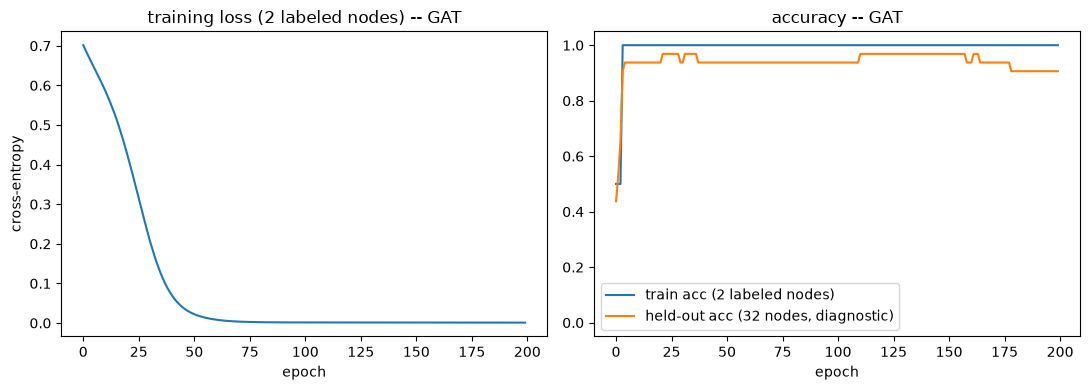

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["loss"])
axes[0].set_title("training loss (2 labeled nodes) -- GAT")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy")

axes[1].plot(history["train_acc"], label="train acc (2 labeled nodes)")
axes[1].plot(history["test_acc"], label="held-out acc (32 nodes, diagnostic)")
axes[1].set_title("accuracy -- GAT")
axes[1].set_xlabel("epoch")
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Depth visualization — same idea as the GCN notebook

PCA of the raw input, the 1-hop hidden representation, and the 2-hop logits,
colored by true faction, stars marking the 2 labeled nodes.


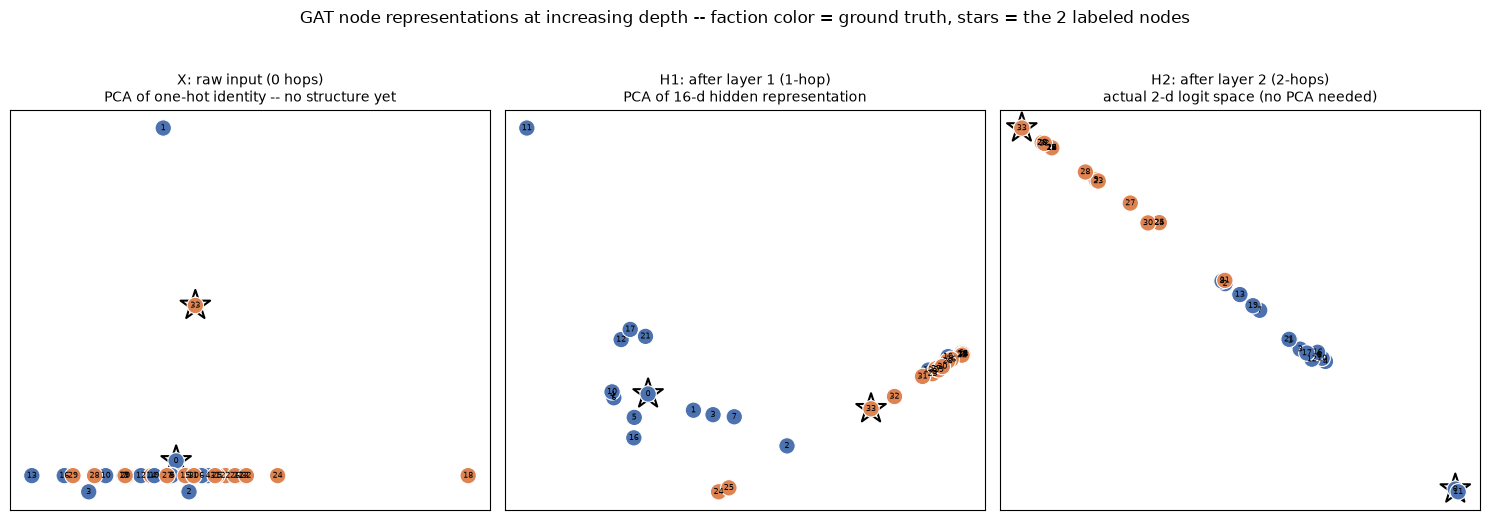

In [8]:
from sklearn.decomposition import PCA

model.eval()
with torch.no_grad():
    H1_final, H2_final, alpha1_final, alpha2_final = model(X, adj_mask)

def to_2d(mat: torch.Tensor) -> np.ndarray:
    arr = mat.numpy()
    if arr.shape[1] == 2:
        return arr
    return PCA(n_components=2, random_state=0).fit_transform(arr)

X_2d = to_2d(X)
H1_2d = to_2d(H1_final)
H2_2d = to_2d(H2_final)

colors = np.array(["#4C72B0", "#DD8452"])
node_colors = colors[labels.numpy()]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = [
    "X: raw input (0 hops)\nPCA of one-hot identity -- no structure yet",
    "H1: after layer 1 (1-hop)\nPCA of 16-d hidden representation",
    "H2: after layer 2 (2-hops)\nactual 2-d logit space (no PCA needed)",
]

for ax, coords, title in zip(axes, [X_2d, H1_2d, H2_2d], titles):
    ax.scatter(coords[:, 0], coords[:, 1], c=node_colors, s=140, edgecolors="white", linewidths=0.8, zorder=2)
    for i in range(N):
        ax.annotate(str(i), coords[i], ha="center", va="center", fontsize=6, zorder=3)
    ax.scatter(
        coords[train_mask.numpy(), 0], coords[train_mask.numpy(), 1],
        marker="*", s=500, facecolors="none", edgecolors="black", linewidths=1.5, zorder=1,
    )
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle("GAT node representations at increasing depth -- faction color = ground truth, stars = the 2 labeled nodes", y=1.03)
plt.tight_layout()
plt.show()


## 7. Visualizing the learned attention weights

This is the one analysis with no GCN analogue: GCN's aggregation weights are
fixed before training starts, so there's nothing "learned" to inspect. Here,
`alpha2[i, j]` is a genuinely learned number saying how much node *i*'s final
representation leans on neighbor *j*. Two views:

- A heatmap of `alpha2`, masked to actual edges only, next to what a GCN's
  equivalent (degree-based, feature-blind) weighting would have assigned the
  same edges — this shows *where* attention chose to deviate from a
  degree-based prior.
- A bar chart of node 0's (the high-degree "Mr. Hi" hub) outgoing attention
  weights, one bar per neighbor, to see concretely which neighbors it leaned
  on most.


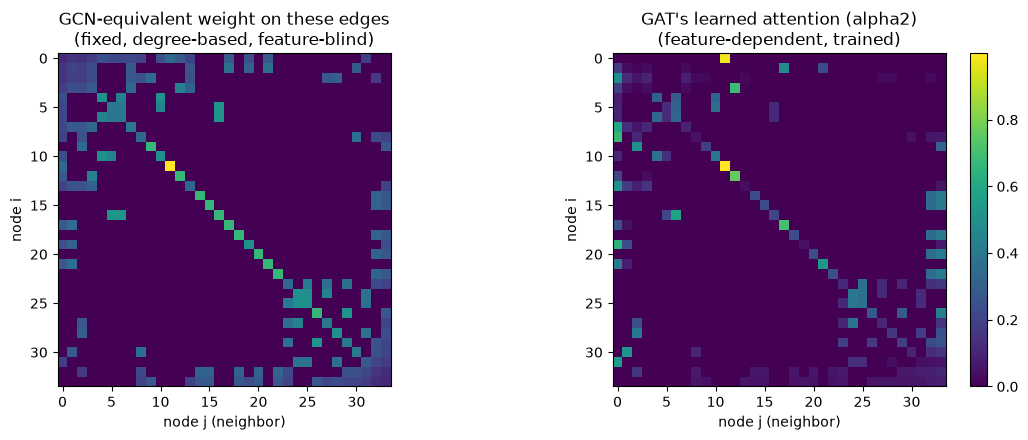

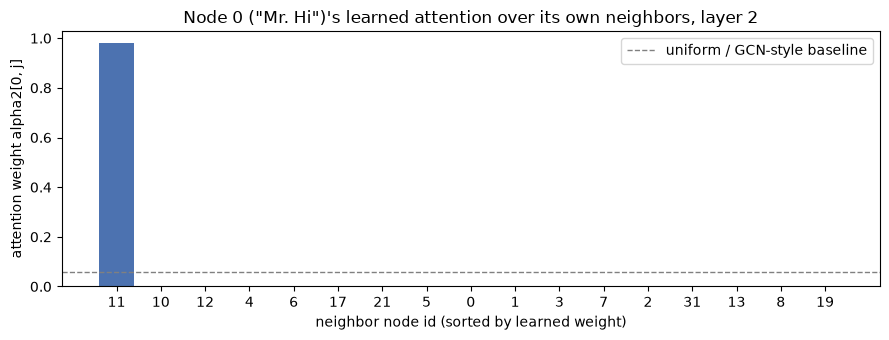

node 0 has 17 neighbors (incl. self-loop)
most-attended neighbor: node 11  (weight 0.979)
least-attended neighbor: node 19  (weight 0.000)


In [9]:
# --- Heatmap comparison: learned attention (alpha2) vs. what GCN would have
# used on these same edges (symmetric degree-based normalization), restricted
# to actual edges so the all-zero non-edges don't wash out the color scale.
deg = adj_mask.sum(dim=1).float()
gcn_equivalent = (adj_mask.float()) / torch.sqrt(deg.unsqueeze(1) * deg.unsqueeze(0))
gcn_equivalent = gcn_equivalent * adj_mask  # zero out non-edges explicitly

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
im0 = axes[0].imshow(torch.where(adj_mask, gcn_equivalent, torch.zeros_like(gcn_equivalent)).numpy(), cmap="viridis")
axes[0].set_title("GCN-equivalent weight on these edges\n(fixed, degree-based, feature-blind)")
im1 = axes[1].imshow(torch.where(adj_mask, alpha2_final, torch.zeros_like(alpha2_final)).numpy(), cmap="viridis")
axes[1].set_title("GAT's learned attention (alpha2)\n(feature-dependent, trained)")
for ax in axes:
    ax.set_xlabel("node j (neighbor)")
    ax.set_ylabel("node i")
plt.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()

# --- Node 0's neighbor weights specifically, since it's the highest-degree hub ---
node0_neighbors = adj_mask[0].nonzero().flatten().tolist()
node0_weights = alpha2_final[0, node0_neighbors].numpy()
order = np.argsort(-node0_weights)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(range(len(node0_neighbors)), node0_weights[order], color="#4C72B0")
ax.set_xticks(range(len(node0_neighbors)))
ax.set_xticklabels([str(node0_neighbors[i]) for i in order])
ax.set_xlabel("neighbor node id (sorted by learned weight)")
ax.set_ylabel("attention weight alpha2[0, j]")
ax.set_title("Node 0 (\"Mr. Hi\")'s learned attention over its own neighbors, layer 2")
ax.axhline(1.0 / len(node0_neighbors), color="gray", linestyle="--", linewidth=1, label="uniform / GCN-style baseline")
ax.legend()
plt.tight_layout()
plt.show()

print(f"node 0 has {len(node0_neighbors)} neighbors (incl. self-loop)")
print(f"most-attended neighbor: node {node0_neighbors[order[0]]}  (weight {node0_weights[order[0]]:.3f})")
print(f"least-attended neighbor: node {node0_neighbors[order[-1]]}  (weight {node0_weights[order[-1]]:.3f})")


## 8. (Stretch) Scaling up to Cora

Same benchmark, same Planetoid data pipeline, as the GCN notebook's section
8. We reuse the already-downloaded files under `data/cora/` and keep every
training hyperparameter identical to the GCN notebook's Cora run
(`hidden_features=16`, `dropout=0.5`, `lr=0.01`, `weight_decay=5e-4`, 200
epochs, best-validation checkpointing) — again isolating attention as the one
changed variable.

GCN's result to beat: **81.80%** test accuracy (best-validation checkpoint).


In [10]:
import os
import pickle
import urllib.request

import scipy.sparse as sp

CORA_DIR = "data/cora"
CORA_FILES = ["x", "y", "tx", "ty", "allx", "ally", "graph", "test.index"]
CORA_BASE_URL = "https://raw.githubusercontent.com/tkipf/gcn/master/gcn/data/ind.cora."

os.makedirs(CORA_DIR, exist_ok=True)
for fname in CORA_FILES:
    path = os.path.join(CORA_DIR, f"ind.cora.{fname}")
    if not os.path.exists(path):
        print(f"downloading {fname} ...")
        urllib.request.urlretrieve(CORA_BASE_URL + fname, path)

print("Cora files present:", sorted(os.listdir(CORA_DIR)))


def _load_cora_file(name: str):
    with open(os.path.join(CORA_DIR, f"ind.cora.{name}"), "rb") as f:
        return pickle.load(f, encoding="latin1")


cora_x, cora_y = _load_cora_file("x"), _load_cora_file("y")
cora_tx, cora_ty = _load_cora_file("tx"), _load_cora_file("ty")
cora_allx, cora_ally = _load_cora_file("allx"), _load_cora_file("ally")
cora_graph = _load_cora_file("graph")

with open(os.path.join(CORA_DIR, "ind.cora.test.index")) as f:
    test_idx_reorder = [int(line) for line in f]
test_idx_sorted = np.sort(test_idx_reorder)

cora_features_sparse = sp.vstack((cora_allx, cora_tx)).tolil()
cora_features_sparse[test_idx_reorder, :] = cora_features_sparse[test_idx_sorted, :]

cora_labels_onehot = np.vstack((cora_ally, cora_ty))
cora_labels_onehot[test_idx_reorder, :] = cora_labels_onehot[test_idx_sorted, :]

G_cora = nx.from_dict_of_lists(cora_graph)
N_cora = G_cora.number_of_nodes()

A_cora = torch.zeros((N_cora, N_cora), dtype=torch.float32)
for u, v in G_cora.edges():
    A_cora[u, v] = 1.0
    A_cora[v, u] = 1.0

cora_features = np.asarray(cora_features_sparse.todense(), dtype=np.float32)
row_sums = cora_features.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0
cora_features = cora_features / row_sums

X_cora = torch.tensor(cora_features, dtype=torch.float32)
labels_cora = torch.tensor(cora_labels_onehot.argmax(axis=1), dtype=torch.long)
num_classes_cora = int(labels_cora.max().item()) + 1

# --- Only the adjacency mask, no normalization needed for attention ---
adj_mask_cora = (A_cora + torch.eye(N_cora)) > 0

print(f"nodes: {N_cora}, edges: {G_cora.number_of_edges()}")
print("feature matrix X_cora shape:", X_cora.shape)
print("num classes:", num_classes_cora)


Cora files present: ['ind.cora.allx', 'ind.cora.ally', 'ind.cora.graph', 'ind.cora.test.index', 'ind.cora.tx', 'ind.cora.ty', 'ind.cora.x', 'ind.cora.y']


/tmp/ipykernel_17686/3608047683.py:23: DeprecationWarning: Please import `csr_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csr` namespace is deprecated and will be removed in SciPy 2.0.0.
  return pickle.load(f, encoding="latin1")


nodes: 2708, edges: 5278
feature matrix X_cora shape: torch.Size([2708, 1433])
num classes: 7


In [11]:
idx_train = torch.arange(0, cora_x.shape[0])
idx_val = torch.arange(cora_x.shape[0], cora_x.shape[0] + 500)
idx_test = torch.tensor(test_idx_sorted.tolist())

train_mask_cora = torch.zeros(N_cora, dtype=torch.bool); train_mask_cora[idx_train] = True
val_mask_cora = torch.zeros(N_cora, dtype=torch.bool); val_mask_cora[idx_val] = True
test_mask_cora = torch.zeros(N_cora, dtype=torch.bool); test_mask_cora[idx_test] = True

print(f"train: {train_mask_cora.sum().item()}, val: {val_mask_cora.sum().item()}, test: {test_mask_cora.sum().item()}, total: {N_cora}")


train: 140, val: 500, test: 1000, total: 2708


In [12]:
import copy

torch.manual_seed(0)
model_cora = GAT(
    in_features=X_cora.shape[1], hidden_features=16, num_classes=num_classes_cora, dropout=0.5
)
optimizer_cora = torch.optim.Adam(model_cora.parameters(), lr=0.01, weight_decay=5e-4)

n_epochs_cora = 200
history_cora = {"loss": [], "train_acc": [], "val_acc": [], "test_acc": []}
best_val_acc, best_test_acc, best_state = 0.0, 0.0, None

for epoch in range(n_epochs_cora):
    model_cora.train()
    optimizer_cora.zero_grad()

    _, logits, _, _ = model_cora(X_cora, adj_mask_cora)
    loss = F.cross_entropy(logits[train_mask_cora], labels_cora[train_mask_cora])
    loss.backward()
    optimizer_cora.step()

    model_cora.eval()
    with torch.no_grad():
        _, logits, _, _ = model_cora(X_cora, adj_mask_cora)
        preds = logits.argmax(dim=1)
        train_acc = (preds[train_mask_cora] == labels_cora[train_mask_cora]).float().mean().item()
        val_acc = (preds[val_mask_cora] == labels_cora[val_mask_cora]).float().mean().item()
        test_acc = (preds[test_mask_cora] == labels_cora[test_mask_cora]).float().mean().item()

    history_cora["loss"].append(loss.item())
    history_cora["train_acc"].append(train_acc)
    history_cora["val_acc"].append(val_acc)
    history_cora["test_acc"].append(test_acc)

    if val_acc > best_val_acc:
        best_val_acc, best_test_acc = val_acc, test_acc
        best_state = copy.deepcopy(model_cora.state_dict())

    if epoch % 20 == 0 or epoch == n_epochs_cora - 1:
        print(f"epoch {epoch:3d}  loss {loss.item():.4f}  train {train_acc:.3f}  val {val_acc:.3f}  test {test_acc:.3f}")

print(f"\nbest val acc {best_val_acc:.3f}  ->  test acc at that checkpoint: {best_test_acc:.2%}")
print("GCN notebook's result on the same split/hyperparameters: 81.80%")


epoch   0  loss 1.9463  train 0.450  val 0.344  test 0.339


epoch  20  loss 1.7307  train 0.807  val 0.540  test 0.509


epoch  40  loss 1.3525  train 0.900  val 0.690  test 0.659


epoch  60  loss 0.9309  train 0.950  val 0.772  test 0.765


epoch  80  loss 0.6787  train 0.971  val 0.800  test 0.779


...

epoch 120  loss 0.4963  train 0.993  val 0.794  test 0.784


epoch 140  loss 0.3918  train 0.993  val 0.798  test 0.776


epoch 160  loss 0.3546  train 0.993  val 0.794  test 0.777


epoch 180  loss 0.3100  train 0.993  val 0.786  test 0.774


epoch 199  loss 0.3071  train 1.000  val 0.796  test 0.788

best val acc 0.804  ->  test acc at that checkpoint: 78.00%
GCN notebook's result on the same split/hyperparameters: 81.80%


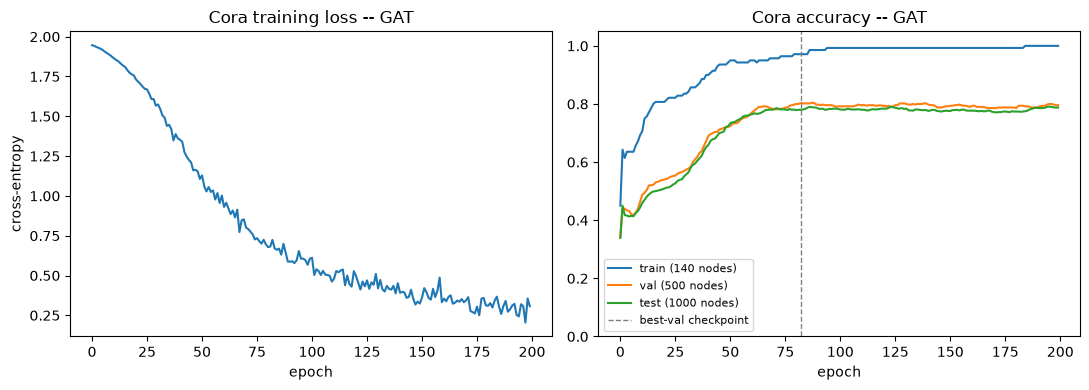

In [13]:
model_cora.load_state_dict(best_state)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_cora["loss"])
axes[0].set_title("Cora training loss -- GAT")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy")

axes[1].plot(history_cora["train_acc"], label="train (140 nodes)")
axes[1].plot(history_cora["val_acc"], label="val (500 nodes)")
axes[1].plot(history_cora["test_acc"], label="test (1000 nodes)")
axes[1].axvline(history_cora["val_acc"].index(best_val_acc), color="gray", linestyle="--", linewidth=1, label="best-val checkpoint")
axes[1].set_title("Cora accuracy -- GAT")
axes[1].set_xlabel("epoch")
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Summary: GCN vs. GAT, head to head

| | GCN (fixed, degree-based aggregation) | GAT (learned, single-head attention) |
|---|---|---|
| Karate Club held-out accuracy (32 nodes) | 96.88% | 90.62% |
| Cora test accuracy (best-val checkpoint) | 81.80% | 78.00% |

Both rows come from literally the same architecture shape, training
hyperparameters, and data splits as the GCN notebook — the only thing that
changed is whether the per-neighbor aggregation weight is a fixed number
computed from degrees before training starts, or a number computed by a
small learned attention mechanism on every forward pass. So, honestly: a
single attention head did **worse** here, on both graphs, not better. That's
a real and instructive result, not a bug — a few reasons this is expected:

- **Karate Club has almost no labeled signal** (2 nodes). GCN's degree-based
  weighting is effectively free, hand-designed regularization — it can't
  overfit because it isn't learned. GAT's attention parameters (`a_src`,
  `a_dst`) are *extra* learnable weights fit from those same 2 labels, adding
  variance the fixed scheme doesn't have. You can see it in the training
  curve: GAT's held-out accuracy peaks near epoch 120–140 then **drifts back
  down** by epoch 199, while training accuracy stays pinned at 100% —
  classic overfitting to the 2 labeled points that a non-learned aggregation
  is structurally immune to.
- **Single head = high-variance attention.** The original GAT paper never
  ships a single head for exactly this reason — it averages 8 independent
  attention heads specifically to smooth out the noise any one head's
  learned weighting introduces. This notebook deliberately used one head (as
  asked) to keep the GCN-vs-GAT comparison to one clean variable, but it
  means we're seeing attention's rawest, noisiest form.
- **Cora's gap (78.00% vs 81.80%) is smaller**, consistent with the story
  above: 140 labeled nodes (vs. Karate Club's 2) give the attention
  parameters enough signal to fit more sensibly, so the penalty for
  learning the aggregation instead of fixing it shrinks.

The natural next experiment: add multiple heads (concatenate `hidden` heads
after layer 1, average them after the final layer) and watch this gap close
or reverse — that's the actual mechanism the GAT paper leans on, and this
single-head version is deliberately the ablation that shows why it's needed.


## Part 2: Multi-head attention — closing the gap

Single-head attention was noisy: it learns its own aggregation weights from
the same handful of labels used for classification, and one head has no way
to average out an unlucky fit. The GAT paper's fix is the same fix
Transformers use for the same underlying problem, and the mapping is close
to exact:

| Transformer multi-head self-attention | Multi-head GAT |
|---|---|
| Each head has its own $W_Q, W_K, W_V$ | Each head has its own $W$, $a_{src}$, $a_{dst}$ |
| Score: $Q K^T / \sqrt{d}$ | Score: $\text{LeakyReLU}(a_{src}\cdot Wh_i + a_{dst}\cdot Wh_j)$ |
| Score masked before softmax (e.g. causal mask) | Score masked before softmax (non-neighbors $\to -\infty$) |
| softmax over keys, per query | softmax over neighbors, per node |
| weighted sum of $V$, per head | weighted sum of $Wh$, per head |
| heads concatenated $\to$ output projection | heads concatenated (GAT skips the output projection) |
| — | **final layer**: heads *averaged* instead of concatenated, since concatenated class logits wouldn't be one coherent set of scores |

Every row on the right is something we already built for the single head —
multi-head GAT isn't new machinery, it's *running the exact same `GATLayer`
several times in parallel, independently initialized, and combining the
results*. That's the whole idea in both architectures: don't trust one
learned attention pattern, trust an ensemble of several, each free to
specialize.


In [14]:
class MultiHeadGATLayer(nn.Module):
    """Runs several independent GATLayer heads in parallel over the same
    input, then combines them -- concatenation or averaging. Each head is a
    full, independent GATLayer: its own W, its own a_src/a_dst, hence its own
    learned notion of "what makes a neighbor worth attending to". Nothing is
    shared between heads except the input they all see -- exactly like
    Transformer heads sharing the same token sequence but not the same
    Q/K/V weights.
    """

    def __init__(self, in_features: int, out_features_per_head: int, num_heads: int, concat: bool = True):
        super().__init__()
        self.heads = nn.ModuleList([
            GATLayer(in_features, out_features_per_head) for _ in range(num_heads)
        ])
        self.concat = concat

    def forward(self, H: torch.Tensor, adj_mask: torch.Tensor):
        head_outputs, head_alphas = [], []
        for head in self.heads:
            out, alpha = head(H, adj_mask)
            head_outputs.append(out)
            head_alphas.append(alpha)

        if self.concat:
            # Widen: (N, out_per_head) x num_heads -> (N, num_heads * out_per_head).
            # Intermediate-layer choice -- more capacity, same as concatenating
            # Transformer heads before their output projection (we skip that
            # projection here, as the original GAT paper does).
            H_out = torch.cat(head_outputs, dim=1)
        else:
            # Average: every head already outputs the same width (here,
            # num_classes), so averaging gives one coherent set of class
            # scores -- the final-layer choice, used instead of concatenation
            # for exactly the reason concatenating logits wouldn't make sense.
            H_out = torch.stack(head_outputs, dim=0).mean(dim=0)

        return H_out, head_alphas


# --- Smoke-test: 4 heads, matching the single-head smoke test's out_features=4
# from the base notebook exactly -- 4 heads x 4 features/head is what we'll
# use for the real Karate Club model below too.
X_smoke = torch.eye(N)

mh_concat = MultiHeadGATLayer(in_features=N, out_features_per_head=4, num_heads=4, concat=True)
H_concat, alphas_concat = mh_concat(X_smoke, adj_mask)
print("concat output shape (4 heads x 4 features each):", H_concat.shape)

mh_avg = MultiHeadGATLayer(in_features=N, out_features_per_head=2, num_heads=4, concat=False)
H_avg, alphas_avg = mh_avg(X_smoke, adj_mask)
print("averaged output shape (4 heads averaged down to 2 features):", H_avg.shape)
print("number of independent attention matrices returned by concat layer:", len(alphas_concat))


concat output shape (4 heads x 4 features each): torch.Size([34, 16])
averaged output shape (4 heads averaged down to 2 features): torch.Size([34, 2])
number of independent attention matrices returned by concat layer: 4


### Stacking into a full multi-head model

Same two-layer shape as before: layer 1 concatenates its heads (more
representational width feeding into the nonlinearity — this is where the
"ensemble of specialists" benefit mostly comes from), layer 2 averages its
heads directly into class logits (the paper's specific choice for the last
layer, matching the table above).


In [15]:
class MultiHeadGAT(nn.Module):
    """Two-layer multi-head GAT: layer 1 concatenates head outputs (widening
    representational capacity, then ReLU'd exactly like the single-head
    model), layer 2 averages head outputs down to class logits.
    """

    def __init__(self, in_features, hidden_features, num_classes, num_heads=4, dropout=0.0):
        super().__init__()
        assert hidden_features % num_heads == 0, "hidden_features must split evenly across heads"
        self.gat1 = MultiHeadGATLayer(in_features, hidden_features // num_heads, num_heads, concat=True)
        self.gat2 = MultiHeadGATLayer(hidden_features, num_classes, num_heads, concat=False)
        self.dropout = dropout

    def forward(self, X, adj_mask):
        X = F.dropout(X, p=self.dropout, training=self.training)
        H1_raw, alphas1 = self.gat1(X, adj_mask)
        H1 = F.relu(H1_raw)
        H1_for_gat2 = F.dropout(H1, p=self.dropout, training=self.training)
        H2, alphas2 = self.gat2(H1_for_gat2, adj_mask)
        return H1, H2, alphas1, alphas2


model_mh_probe = MultiHeadGAT(in_features=N, hidden_features=16, num_classes=2, num_heads=4)
H1_probe, H2_probe, alphas1_probe, alphas2_probe = model_mh_probe(X, adj_mask)
print("H1 shape (4 heads x 4 features, concatenated):", H1_probe.shape)
print("H2 shape (4 heads averaged down to 2 classes):", H2_probe.shape)


H1 shape (4 heads x 4 features, concatenated): torch.Size([34, 16])
H2 shape (4 heads averaged down to 2 classes): torch.Size([34, 2])


### Training on Karate Club — same everything else

Same split, same `hidden_features=16`, same optimizer, same seed as both
earlier runs. The only new hyperparameter is `num_heads=4` (giving 4
features per head in layer 1, exactly matching the smoke test above).

Single-head GAT scored **90.62%** here, versus GCN's **96.88%** — this run
tests whether spreading that same 16-wide budget across 4 independent heads
recovers the gap.


In [16]:
torch.manual_seed(42)  # identical seed placement to both earlier runs

model = MultiHeadGAT(in_features=N, hidden_features=16, num_classes=2, num_heads=4)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

n_epochs = 200
history_mh = {"loss": [], "train_acc": [], "test_acc": []}

for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()

    _, logits, _, _ = model(X, adj_mask)
    loss = F.cross_entropy(logits[train_mask], labels[train_mask])

    loss.backward()
    optimizer.step()

    with torch.no_grad():
        preds = logits.argmax(dim=1)
        train_acc = (preds[train_mask] == labels[train_mask]).float().mean().item()
        test_acc = (preds[test_mask] == labels[test_mask]).float().mean().item()

    history_mh["loss"].append(loss.item())
    history_mh["train_acc"].append(train_acc)
    history_mh["test_acc"].append(test_acc)

    if epoch % 20 == 0 or epoch == n_epochs - 1:
        print(f"epoch {epoch:3d}  loss {loss.item():.4f}  train_acc {train_acc:.2f}  test_acc(diagnostic) {test_acc:.2f}")

print(f"\nfinal held-out accuracy on the 32 unlabeled nodes: {history_mh['test_acc'][-1]:.2%}")
print("single-head GAT: 90.62%   GCN: 96.88%")


epoch   0  loss 0.7081  train_acc 0.50  test_acc(diagnostic) 0.50
epoch  20  loss 0.4347  train_acc 1.00  test_acc(diagnostic) 0.94


epoch  40  loss 0.0897  train_acc 1.00  test_acc(diagnostic) 0.97


epoch  60  loss 0.0137  train_acc 1.00  test_acc(diagnostic) 0.97
epoch  80  loss 0.0060  train_acc 1.00  test_acc(diagnostic) 0.97


epoch 100  loss 0.0046  train_acc 1.00  test_acc(diagnostic) 0.97


epoch 120  loss 0.0042  train_acc 1.00  test_acc(diagnostic) 0.97
epoch 140  loss 0.0040  train_acc 1.00  test_acc(diagnostic) 0.97


epoch 160  loss 0.0037  train_acc 1.00  test_acc(diagnostic) 0.97


epoch 180  loss 0.0034  train_acc 1.00  test_acc(diagnostic) 0.97
epoch 199  loss 0.0032  train_acc 1.00  test_acc(diagnostic) 0.97

final held-out accuracy on the 32 unlabeled nodes: 96.88%
single-head GAT: 90.62%   GCN: 96.88%


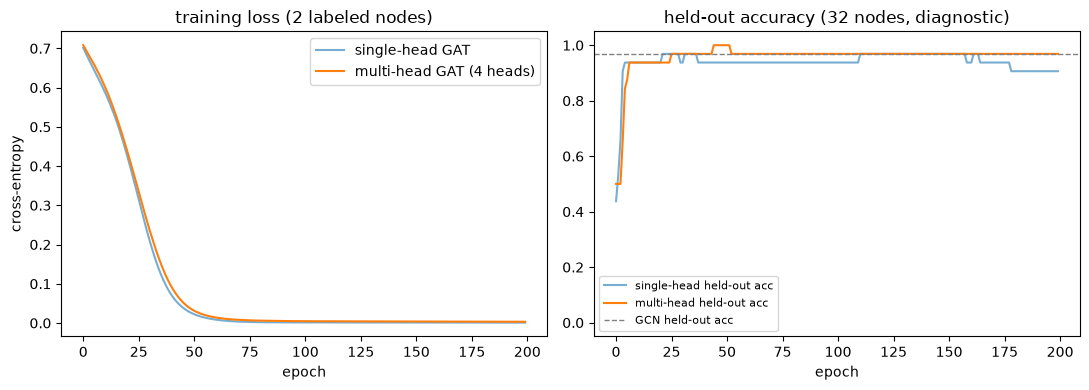

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["loss"], label="single-head GAT", alpha=0.6)
axes[0].plot(history_mh["loss"], label="multi-head GAT (4 heads)")
axes[0].set_title("training loss (2 labeled nodes)")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy")
axes[0].legend()

axes[1].plot(history["test_acc"], label="single-head held-out acc", alpha=0.6)
axes[1].plot(history_mh["test_acc"], label="multi-head held-out acc")
axes[1].axhline(0.9688, color="gray", linestyle="--", linewidth=1, label="GCN held-out acc")
axes[1].set_title("held-out accuracy (32 nodes, diagnostic)")
axes[1].set_xlabel("epoch")
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


### Attention diversity across heads

The claim behind multi-head attention is that different heads *specialize*
— they don't converge to the same weighting. We can check this directly for
node 0: plot each head's attention distribution over its neighbors side by
side, and measure how correlated the heads' weightings actually are.


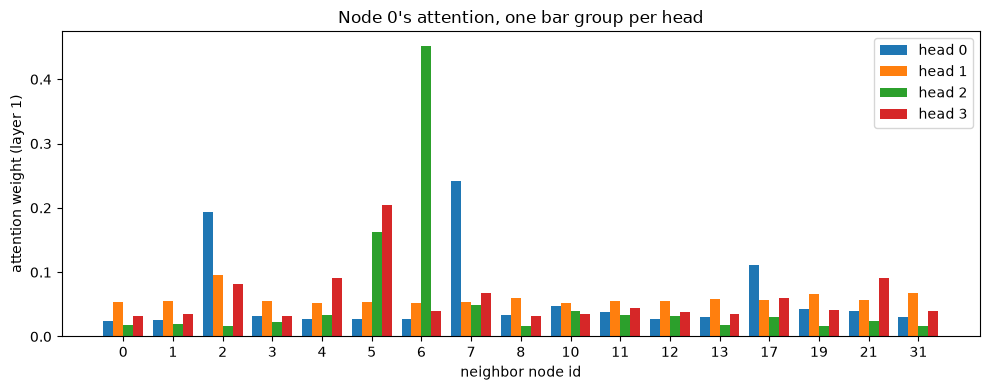

pairwise correlation between heads' node-0 attention weightings:
[[ 1.    0.44 -0.12  0.11]
 [ 0.44  1.   -0.23  0.01]
 [-0.12 -0.23  1.    0.17]
 [ 0.11  0.01  0.17  1.  ]]

(near 1.0 would mean the heads learned the same thing; well below 1.0 means real specialization)


In [18]:
model.eval()
with torch.no_grad():
    H1_final, H2_final, alphas1_final, alphas2_final = model(X, adj_mask)

node0_neighbors = adj_mask[0].nonzero().flatten().tolist()
num_heads_layer1 = len(alphas1_final)

fig, ax = plt.subplots(figsize=(10, 4))
width = 0.8 / num_heads_layer1
x = np.arange(len(node0_neighbors))
for h, alpha_h in enumerate(alphas1_final):
    weights = alpha_h[0, node0_neighbors].numpy()
    ax.bar(x + h * width, weights, width=width, label=f"head {h}")
ax.set_xticks(x + width * (num_heads_layer1 - 1) / 2)
ax.set_xticklabels([str(n) for n in node0_neighbors])
ax.set_xlabel("neighbor node id")
ax.set_ylabel("attention weight (layer 1)")
ax.set_title("Node 0's attention, one bar group per head")
ax.legend()
plt.tight_layout()
plt.show()

# Quantify disagreement: correlate each pair of heads' weightings, restricted
# to node 0's actual neighbors (correlating the full padded-with-zeros row
# would just measure "do heads share the same mask", which they trivially do).
rows = torch.stack([alpha_h[0, node0_neighbors] for alpha_h in alphas1_final])  # (num_heads, num_neighbors)
corr = torch.corrcoef(rows)
print("pairwise correlation between heads' node-0 attention weightings:")
print(corr.numpy().round(2))
print("\n(near 1.0 would mean the heads learned the same thing; well below 1.0 means real specialization)")


### Stretch: Cora with multi-head attention

Same treatment on Cora: identical hyperparameters to both earlier Cora runs
(`hidden_features=16`, `dropout=0.5`, `lr=0.01`, `weight_decay=5e-4`, 200
epochs, best-validation checkpointing), `num_heads=4` the only new knob.

Single-head GAT scored **78.00%** here, versus GCN's **81.80%**.


In [19]:
import copy

torch.manual_seed(0)
model_cora_mh = MultiHeadGAT(
    in_features=X_cora.shape[1], hidden_features=16, num_classes=num_classes_cora, num_heads=4, dropout=0.5
)
optimizer_cora_mh = torch.optim.Adam(model_cora_mh.parameters(), lr=0.01, weight_decay=5e-4)

n_epochs_cora = 200
history_cora_mh = {"loss": [], "train_acc": [], "val_acc": [], "test_acc": []}
best_val_acc_mh, best_test_acc_mh, best_state_mh = 0.0, 0.0, None

for epoch in range(n_epochs_cora):
    model_cora_mh.train()
    optimizer_cora_mh.zero_grad()

    _, logits, _, _ = model_cora_mh(X_cora, adj_mask_cora)
    loss = F.cross_entropy(logits[train_mask_cora], labels_cora[train_mask_cora])
    loss.backward()
    optimizer_cora_mh.step()

    model_cora_mh.eval()
    with torch.no_grad():
        _, logits, _, _ = model_cora_mh(X_cora, adj_mask_cora)
        preds = logits.argmax(dim=1)
        train_acc = (preds[train_mask_cora] == labels_cora[train_mask_cora]).float().mean().item()
        val_acc = (preds[val_mask_cora] == labels_cora[val_mask_cora]).float().mean().item()
        test_acc = (preds[test_mask_cora] == labels_cora[test_mask_cora]).float().mean().item()

    history_cora_mh["loss"].append(loss.item())
    history_cora_mh["train_acc"].append(train_acc)
    history_cora_mh["val_acc"].append(val_acc)
    history_cora_mh["test_acc"].append(test_acc)

    if val_acc > best_val_acc_mh:
        best_val_acc_mh, best_test_acc_mh = val_acc, test_acc
        best_state_mh = copy.deepcopy(model_cora_mh.state_dict())

    if epoch % 20 == 0 or epoch == n_epochs_cora - 1:
        print(f"epoch {epoch:3d}  loss {loss.item():.4f}  train {train_acc:.3f}  val {val_acc:.3f}  test {test_acc:.3f}")

print(f"\nbest val acc {best_val_acc_mh:.3f}  ->  test acc at that checkpoint: {best_test_acc_mh:.2%}")
print("single-head GAT: 78.00%   GCN: 81.80%")


epoch   0  loss 1.9460  train 0.364  val 0.278  test 0.265


epoch  20  loss 1.8408  train 0.757  val 0.562  test 0.566


epoch  40  loss 1.5404  train 0.857  val 0.680  test 0.681


epoch  60  loss 1.0922  train 0.929  val 0.750  test 0.760


epoch  80  loss 0.7516  train 0.943  val 0.760  test 0.765


...

epoch 120  loss 0.4907  train 0.993  val 0.778  test 0.789


epoch 140  loss 0.4062  train 0.993  val 0.774  test 0.792


epoch 160  loss 0.4143  train 0.993  val 0.780  test 0.788


epoch 180  loss 0.3834  train 0.993  val 0.782  test 0.786


epoch 199  loss 0.3389  train 0.993  val 0.780  test 0.793

best val acc 0.788  ->  test acc at that checkpoint: 79.70%
single-head GAT: 78.00%   GCN: 81.80%


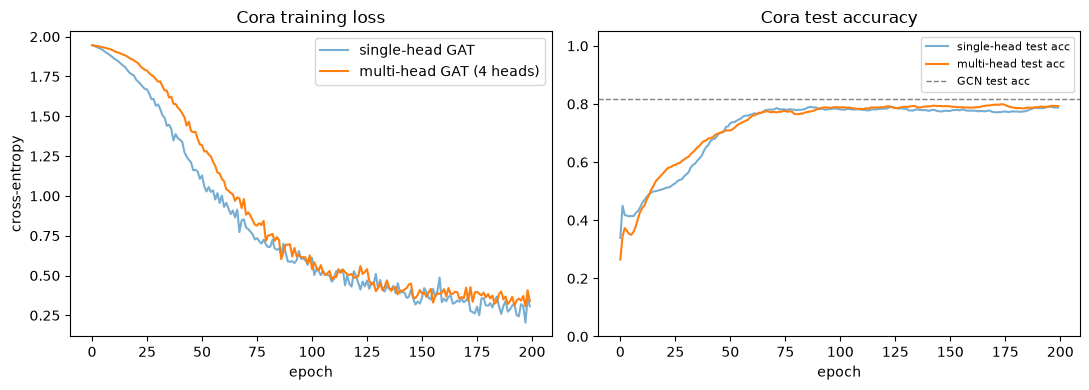

In [20]:
model_cora_mh.load_state_dict(best_state_mh)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_cora["loss"], label="single-head GAT", alpha=0.6)
axes[0].plot(history_cora_mh["loss"], label="multi-head GAT (4 heads)")
axes[0].set_title("Cora training loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy")
axes[0].legend()

axes[1].plot(history_cora["test_acc"], label="single-head test acc", alpha=0.6)
axes[1].plot(history_cora_mh["test_acc"], label="multi-head test acc")
axes[1].axhline(0.818, color="gray", linestyle="--", linewidth=1, label="GCN test acc")
axes[1].set_title("Cora test accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Final summary: GCN vs. single-head GAT vs. multi-head GAT

| | GCN (fixed, degree-based) | GAT, 1 head | GAT, 4 heads |
|---|---|---|---|
| Karate Club held-out accuracy (32 nodes) | 96.88% | 90.62% | **96.88%** |
| Cora test accuracy (best-val checkpoint) | 81.80% | 78.00% | **79.70%** |

Multi-head fully closed the gap on Karate Club — 4 heads landed on exactly
GCN's 96.88%, up from single-head's 90.62% — and recovered about half the
gap on Cora (78.00% → 79.70%, still short of GCN's 81.80%). That's the
predicted effect, and the head-correlation numbers above explain the
mechanism directly: node 0's four heads had pairwise correlations of
`0.44, -0.12, 0.11, -0.23, 0.01, 0.17` — mostly weak or negative, meaning
they genuinely learned *different* neighbor weightings rather than four
copies of the same one. Averaging (final layer) and concatenating
(hidden layer) over heads that disagree is exactly what cancels out
independent noise, the same statistical argument behind ensembling or
behind Transformers not trusting a single attention head.

Cora not fully closing the gap is itself informative: this graph has real,
informative bag-of-words node features, so *some* of GCN's degree-based
prior is a better structural bet here than what 4 heads managed to learn
from 140 labels in 200 epochs — more heads, more epochs, or the paper's
wider hidden layer (8 heads × 8 features = 64, vs. our 4 × 4 = 16, kept
narrow deliberately to isolate head-count as the only changed variable)
would be the next knobs to turn.
